 ### BANK LENDING DATA PREDICTION NOTEBOOK!

### importing the libraries

In [266]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from codecarbon import EmissionsTracker
import numpy as np
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_column",100)
pd.set_option("display.max_rows",100)

### Reading the file

In [267]:
#Reading the file
data = pd.read_csv('/home/enginelab/Everton /XYZ_CorpLending/XYZCorp_LendingData.txt',
                      index_col=0, delimiter='\t',parse_dates=['issue_d'])

### Data Splitting

*** we'll split data split as per given problem statement condition..

In [268]:
data

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,2011-12-01,n,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,1.0,NaN,NaN,3.0,0.0,13648.0,83.7,9.0,f,0.00,0.00,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-2015,171.62,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,2011-12-01,n,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-1999,5.0,NaN,NaN,3.0,0.0,1687.0,9.4,4.0,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-2013,119.66,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,2011-12-01,n,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,2.0,NaN,NaN,2.0,0.0,2956.0,98.5,10.0,f,0.00,0.00,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-2014,649.91,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,2011-12-01,n,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-1996,1.0,35.0,NaN,10.0,0.0,5598.0,21.0,37.0,f,0.00,0.00,12226.302212,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-2015,357.48,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,2011-12-01,n,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-1996,0.0,38.0,NaN,15.0,0.0,27783.0,53.9,38.0,f,766.90,766.90,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-2016,67.79,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36371250,39102635,10000.0,10000.0,10000.0,36 months,11.99,332.10,B,B5,Office Assistant,8 years,RENT,31000.0,Verified,2015-01-01,n,NaN,debt_consolidation,Debt consolidation,905xx,CA,28.69,0.0,Sep-2004,0.0,NaN,77.0,9.0,1.0,14037.0,82.1,15.0,f,7055.47,7055.47,3971.880000,3971.88,2944.53,1027.35,0.00,0.00,0.00,Jan-2016,332.10,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,25274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

### Data Pre-processing

#Printing the shape of both splitted dataset to get counts of variables and observations...

In [269]:
data.isnull().sum().sort_values(ascending=False)

dti_joint                      855529
annual_inc_joint               855527
verification_status_joint      855527
il_util                        844360
mths_since_rcnt_il             843035
max_bal_bc                     842681
open_rv_24m                    842681
open_acc_6m                    842681
total_cu_tl                    842681
inq_fi                         842681
all_util                       842681
open_il_6m                     842681
open_il_24m                    842681
open_il_12m                    842681
total_bal_il                   842681
open_rv_12m                    842681
inq_last_12m                   842681
desc                           734159
mths_since_last_record         724785
mths_since_last_major_derog    642830
mths_since_last_delinq         439812
next_pymnt_d                   252971
tot_coll_amt                    67313
total_rev_hi_lim                67313
tot_cur_bal                     67313
emp_title                       49443
emp_length  

#Imprimindo um resumo conciso do DataFrame 'train_df', exibindo informações como: tipos de dados (dtypes), valores não nulos e uso de memória.

In [270]:
print(data.info())

<class 'pandas.DataFrame'>
Index: 855969 entries, 1077501 to 36271262
Data columns (total 72 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   member_id                    855969 non-null  int64         
 1   loan_amnt                    855969 non-null  float64       
 2   funded_amnt                  855969 non-null  float64       
 3   funded_amnt_inv              855969 non-null  float64       
 4   term                         855969 non-null  str           
 5   int_rate                     855969 non-null  float64       
 6   installment                  855969 non-null  float64       
 7   grade                        855969 non-null  str           
 8   sub_grade                    855969 non-null  str           
 9   emp_title                    806526 non-null  str           
 10  emp_length                   812908 non-null  str           
 11  home_ownership               85596

#Exibe um resumo estatístico básico, como percentis (25%, 50%, 75%), desvio padrão, média, valores mínimo e máximo, e a contagem de registros para as colunas numéricas.

In [271]:
print(data.describe())

          member_id      loan_amnt    funded_amnt  funded_amnt_inv  \
count  8.559690e+05  855969.000000  855969.000000    855969.000000   
mean   3.476269e+07   14745.571335   14732.378305     14700.061226   
min    7.069900e+04     500.000000     500.000000         0.000000   
25%    1.079273e+07    8000.000000    8000.000000      8000.000000   
50%    3.697532e+07   13000.000000   13000.000000     13000.000000   
75%    5.803559e+07   20000.000000   20000.000000     20000.000000   
max    7.351969e+07   35000.000000   35000.000000     35000.000000   
std    2.399418e+07    8425.340005    8419.471653      8425.805478   

            int_rate    installment    annual_inc                     issue_d  \
count  855969.000000  855969.000000  8.559690e+05                      855969   
mean       13.192320     436.238072  7.507119e+04  2014-07-09 23:02:59.808849   
min         5.320000      15.690000  0.000000e+00         2007-06-01 00:00:00   
25%         9.990000     260.550000  4.500000

### Apagando Features.

#### Excluindo variáveis com base em conhecimento de negócio (experiência na área) e gerando o relatório do pandas_profiling.

In [ ]:
cols_to_drop = [
    'collection_recovery_fee',
    'recoveries',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'last_pymnt_amnt',
    'last_pymnt_d',
    'next_pymnt_d',
    'out_prncp',
    'out_prncp_inv',
    'member_id',
    'desc',
    'emp_title',
    'title',
    'annual_inc_joint',
    'dti_joint'
]

data = data.drop(cols_to_drop, axis=1)

#### Verificando os valores ausentes (faltantes) para cada variável presente no conjunto de dados.

In [273]:
data.isnull().sum().sort_values(ascending=False)

verification_status_joint      855527
il_util                        844360
mths_since_rcnt_il             843035
total_bal_il                   842681
all_util                       842681
inq_fi                         842681
inq_last_12m                   842681
max_bal_bc                     842681
open_rv_24m                    842681
open_il_6m                     842681
open_il_24m                    842681
open_il_12m                    842681
open_acc_6m                    842681
open_rv_12m                    842681
total_cu_tl                    842681
mths_since_last_record         724785
mths_since_last_major_derog    642830
mths_since_last_delinq         439812
tot_cur_bal                     67313
total_rev_hi_lim                67313
tot_coll_amt                    67313
emp_length                      43061
revol_util                        446
collections_12_mths_ex_med         56
last_credit_pull_d                 50
dti                                 0
inq_last_6mt

#Criada uma função manual para identificar valores ausentes, ordenando os dados com maior ocorrência de faltas no topo e categorizando-os por contagem e porcentagem.

In [274]:
def missing_data(data):
    total=data.isnull().sum().sort_values(ascending=False)
    percent=(data.isnull().sum()/data.isnull().count()).sort_values(ascending=False)
    missing_data=pd.concat([total,percent],axis=1,keys=['total','percent'])
    return(missing_data.head(20))

In [275]:
missing_data(data)

,total,percent
verification_status_joint,855527,0.999484
il_util,844360,0.986438
mths_since_rcnt_il,843035,0.984890
total_bal_il,842681,0.984476
all_util,842681,0.984476
inq_fi,842681,0.984476
inq_last_12m,842681,0.984476
max_bal_bc,842681,0.984476
open_rv_24m,842681,0.984476
open_il_6m,842681,0.984476


####Agora, veja as colunas restantes no conjunto de dados usando a função abaixo.

In [276]:
print(data.columns)

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose',
       'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'verification_status_joint',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'default_ind'],
      dtype='str')


#### Verificando os registros únicos de uma variável específica.

In [277]:
data['pymnt_plan'].value_counts()

pymnt_plan
n    855964
y         5
Name: count, dtype: int64

#### Gerando o gráfico para verificar a ocorrência dos registros de forma visual.

<Axes: xlabel='pymnt_plan'>

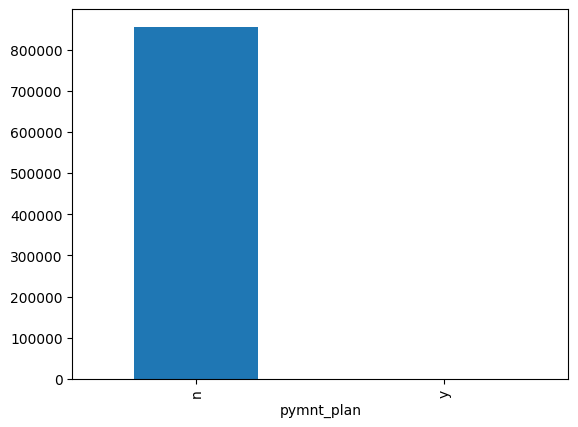

In [278]:
data['pymnt_plan'].value_counts().plot.bar()

#### A contagem da variável 'y' é insignificante, por isso ela será excluída.

In [279]:

del data['pymnt_plan']

### Tratamento de valores ausentes

### Imputação dos valores ausentes para todas as variáveis.

In [280]:
for x in data.columns[:]:
    if data[x].dtype=='str':
        data[x].fillna(data[x].mode()[0],inplace=True) #preenche com a moda
    elif data[x].dtype=='int64' or data[x].dtype=='float64':
        data[x].fillna(data[x].mean(),inplace=True) #preenche com a média

#### Checando valores ausentes

In [281]:
print(data.isnull().sum())

loan_amnt                           0
funded_amnt                         0
funded_amnt_inv                     0
term                                0
int_rate                            0
installment                         0
grade                               0
sub_grade                           0
emp_length                      43061
home_ownership                      0
annual_inc                          0
verification_status                 0
issue_d                             0
purpose                             0
zip_code                            0
addr_state                          0
dti                                 0
delinq_2yrs                         0
earliest_cr_line                    0
inq_last_6mths                      0
mths_since_last_delinq         439812
mths_since_last_record         724785
open_acc                            0
pub_rec                             0
revol_bal                           0
revol_util                        446
total_acc   

In [282]:
print(data.dtypes)

loan_amnt                             float64
funded_amnt                           float64
funded_amnt_inv                       float64
term                                      str
int_rate                              float64
installment                           float64
grade                                     str
sub_grade                                 str
emp_length                                str
home_ownership                            str
annual_inc                            float64
verification_status                       str
issue_d                        datetime64[us]
purpose                                   str
zip_code                                  str
addr_state                                str
dti                                   float64
delinq_2yrs                           float64
earliest_cr_line                          str
inq_last_6mths                        float64
mths_since_last_delinq                float64
mths_since_last_record            

### Convertendo todas as variáveis para numéricas.

#Conversão de variáveis de ponto flutuante para o formato numérico; primeiro, vamos extrair todas as variáveis de ponto flutuante e observar...

In [283]:
colname=[]
for x in data.columns:
    if data[x].dtype=='float64':
        colname.append(x)


#Printando variáveis de ponto flutuante

In [284]:
print(colname)

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m']


In [ ]:
#APLICAÇÃO DO LABEL ENCODER

from sklearn import preprocessing

le=preprocessing.LabelEncoder()

for x in colname:
    data[x]=le.fit_transform(data[x])

In [286]:
print(data.dtypes)

loan_amnt                               int64
funded_amnt                             int64
funded_amnt_inv                         int64
term                                      str
int_rate                                int64
installment                             int64
grade                                     str
sub_grade                                 str
emp_length                                str
home_ownership                            str
annual_inc                              int64
verification_status                       str
issue_d                        datetime64[us]
purpose                                   str
zip_code                                  str
addr_state                                str
dti                                     int64
delinq_2yrs                             int64
earliest_cr_line                          str
inq_last_6mths                          int64
mths_since_last_delinq                  int64
mths_since_last_record            

#### Esta variável é usada para a divisão dos dados e não é significativa para a construção do modelo.

In [287]:
print(data['issue_d'].value_counts())

issue_d
2015-10-01    48212
2015-07-01    44906
2014-10-01    37442
2015-11-01    37211
2015-12-01    35638
              ...  
2007-08-01       33
2008-09-01       32
2007-07-01       30
2007-09-01       18
2007-06-01        1
Name: count, Length: 103, dtype: int64


#### Excluído conforme a explicação acima.

In [288]:
del data['issue_d']

#### Verificando os registros únicos para esta coluna específica.

In [289]:
print(data['zip_code'].value_counts())

zip_code
945xx    9466
750xx    9111
112xx    8894
606xx    8370
300xx    7820
         ... 
399xx       1
343xx       1
649xx       1
862xx       1
507xx       1
Name: count, Length: 931, dtype: int64


#### Zip code foi removido por ser uma variável de texto (varchar) e, portanto, não é significativa para a construção do modelo.

In [290]:
del data['zip_code']

#Verificando os registros únicos para esta variável específica.

In [291]:
print(data['initial_list_status'].value_counts())

initial_list_status
f    442555
w    413414
Name: count, dtype: int64


#### Gerando o gráfico para a representação visual...

<Axes: xlabel='initial_list_status', ylabel='count'>

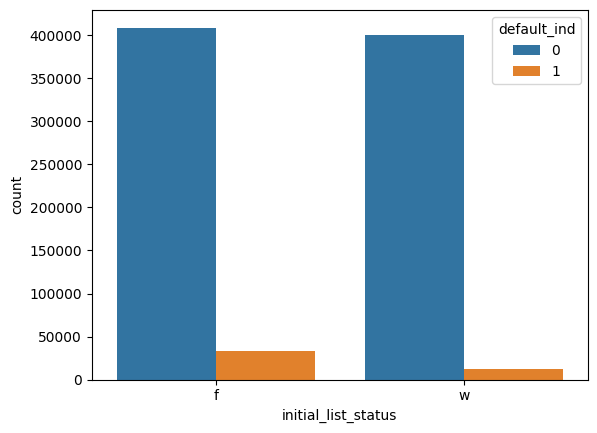

In [292]:
sns.countplot(x='initial_list_status',data=data,hue='default_ind')

#### Fazendo a codificação de rótulos (Label Encoding) manualmente para esta coluna específica.

In [293]:
data['initial_list_status'] = np.where(data['initial_list_status']=='f', 0, data['initial_list_status'])
data['initial_list_status'] = np.where(data['initial_list_status']=='w', 1, data['initial_list_status'])

#### Verificando se foi convertido ou não

In [294]:
print(data['initial_list_status'].value_counts())

initial_list_status
0    442555
1    413414
Name: count, dtype: int64


#### Vamos primeiro verificar o registro único para esta coluna específica.

In [295]:
data['int_rate'].value_counts()

int_rate
110    34056
59     24956
284    24359
80     21315
38     20062
       ...  
365        1
247        1
229        1
514        1
504        1
Name: count, Length: 520, dtype: int64

#### Gerando o gráfico para verificar a distribuição normal da variável; esta variável possui uma simetria perfeita (skewness zero), o que significa que não é enviesada para a direita nem para a esquerda, portanto, vamos mantê-la.

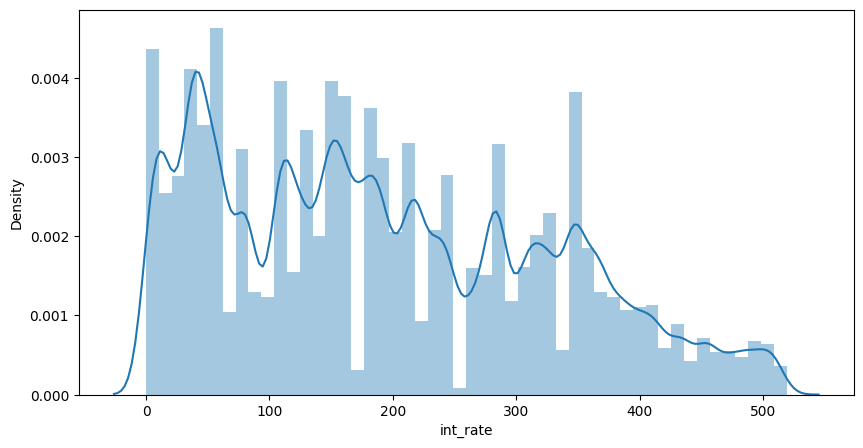

In [296]:
plt.figure(figsize=(10,5))
sns.distplot(data['int_rate'])
plt.show()

#### Esta variável é a nossa variável alvo (target); ao plotar e verificar os registros, o resultado indica dados desbalanceados. Isso fará com que o modelo cometa erros ao ser treinado, pois ele lerá os mesmos valores repetidamente em uma proporção de 9:1, o que levará a previsões falsas (errôneas) sobre os valores de inadimplência (default).

<Axes: xlabel='default_ind'>

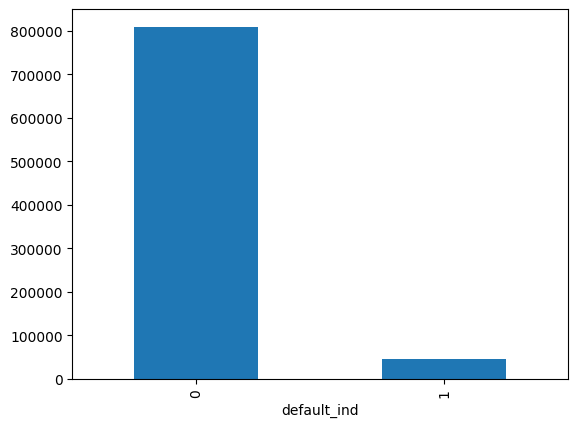

In [297]:
data['default_ind'].value_counts().plot.bar()

####Adicionando todas as variáveis do tipo objeto à lista.

In [298]:
colname=[]
for x in data.columns:
    if data[x].dtype=='str':
        colname.append(x)

In [299]:
print(colname)

['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'earliest_cr_line', 'last_credit_pull_d', 'application_type', 'verification_status_joint']


#### Utilizando a função de Label Encoding, vamos ajustar as variáveis do tipo de dado 'object' (objetos/texto) e transformar os dados para o formato numérico.

In [300]:
from sklearn import preprocessing

le=preprocessing.LabelEncoder()

for x in colname:
    data[x]=le.fit_transform(data[x])

In [301]:
print(data.dtypes)

loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv                 int64
term                            int64
int_rate                        int64
installment                     int64
grade                           int64
sub_grade                       int64
emp_length                      int64
home_ownership                  int64
annual_inc                      int64
verification_status             int64
purpose                         int64
addr_state                      int64
dti                             int64
delinq_2yrs                     int64
earliest_cr_line                int64
inq_last_6mths                  int64
mths_since_last_delinq          int64
mths_since_last_record          int64
open_acc                        int64
pub_rec                         int64
revol_bal                       int64
revol_util                      int64
total_acc                       int64
initial_list_status            object
last_credit_

In [302]:
print(data['emp_length'].value_counts())

emp_length
1     282090
2      75986
10     67597
3      67392
0      54855
5      53812
4      50643
7      43204
11     43061
8      42421
6      41446
9      33462
Name: count, dtype: int64


#### Excluindo as variáveis com base no conhecimento de domínio

In [303]:
data=data.drop(['addr_state', 'earliest_cr_line','last_credit_pull_d', 'policy_code'],axis=1)

In [304]:
data=data.drop(['application_type'],axis=1)

#### Gerando o histograma de todas as variáveis e verificando a distribuição de frequência para as variáveis restantes no conjunto de dados.

array([[<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'funded_amnt'}>,
        <Axes: title={'center': 'funded_amnt_inv'}>,
        <Axes: title={'center': 'term'}>,
        <Axes: title={'center': 'int_rate'}>,
        <Axes: title={'center': 'installment'}>,
        <Axes: title={'center': 'grade'}>],
       [<Axes: title={'center': 'sub_grade'}>,
        <Axes: title={'center': 'emp_length'}>,
        <Axes: title={'center': 'home_ownership'}>,
        <Axes: title={'center': 'annual_inc'}>,
        <Axes: title={'center': 'verification_status'}>,
        <Axes: title={'center': 'purpose'}>,
        <Axes: title={'center': 'dti'}>],
       [<Axes: title={'center': 'delinq_2yrs'}>,
        <Axes: title={'center': 'inq_last_6mths'}>,
        <Axes: title={'center': 'mths_since_last_delinq'}>,
        <Axes: title={'center': 'mths_since_last_record'}>,
        <Axes: title={'center': 'open_acc'}>,
        <Axes: title={'center': 'pub_rec'}>,
        <Axes: titl

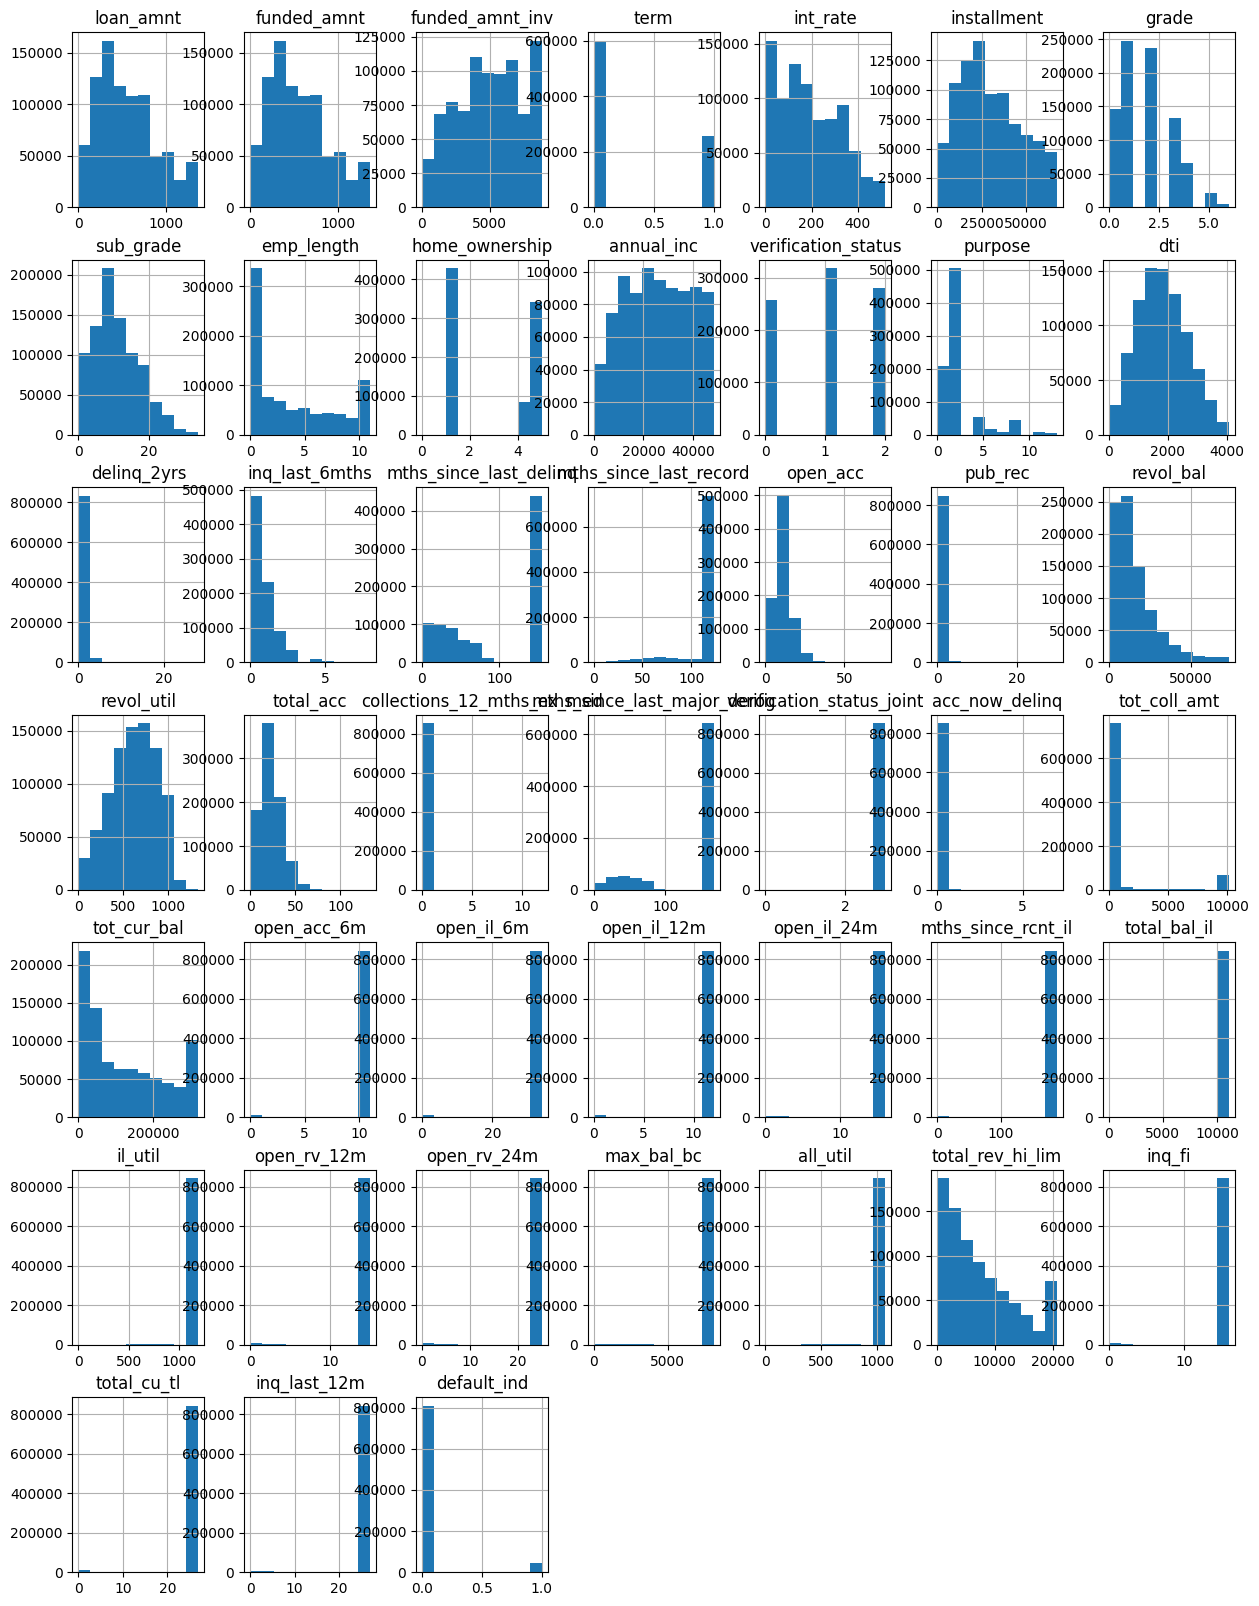

In [305]:
# Plotting histogram of all variables and check out the frequency distribution for remaining variables in the dataset
data.hist(figsize=(15,20))

#### Verificando a correlação para identificar o relacionamento estabelecido entre as variáveis.

In [306]:
data.dtypes

loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv                 int64
term                            int64
int_rate                        int64
installment                     int64
grade                           int64
sub_grade                       int64
emp_length                      int64
home_ownership                  int64
annual_inc                      int64
verification_status             int64
purpose                         int64
dti                             int64
delinq_2yrs                     int64
inq_last_6mths                  int64
mths_since_last_delinq          int64
mths_since_last_record          int64
open_acc                        int64
pub_rec                         int64
revol_bal                       int64
revol_util                      int64
total_acc                       int64
initial_list_status            object
collections_12_mths_ex_med      int64
mths_since_last_major_derog     int64
verification

In [307]:
lis=data[data.columns].corr()['default_ind'][:]
print(data[data.columns].corr()['default_ind'][:])

loan_amnt                     -0.004907
funded_amnt                   -0.005797
funded_amnt_inv               -0.009330
term                           0.031378
int_rate                       0.155715
installment                    0.004626
grade                          0.123656
sub_grade                      0.126923
emp_length                     0.015741
home_ownership                 0.032341
annual_inc                    -0.059897
verification_status            0.039585
purpose                        0.043574
dti                            0.010091
delinq_2yrs                   -0.009188
inq_last_6mths                 0.074407
mths_since_last_delinq         0.018345
mths_since_last_record         0.026744
open_acc                      -0.021702
pub_rec                       -0.020115
revol_bal                     -0.023721
revol_util                     0.044484
total_acc                     -0.021086
initial_list_status           -0.098812
collections_12_mths_ex_med    -0.007572


In [308]:
corr = data.corr()
corr.style.background_gradient(cmap='coolwarm').format(precision=2)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
loan_amnt,1.00,1.00,0.96,0.41,0.14,0.95,0.15,0.16,-0.08,-0.20,0.52,0.28,-0.16,0.04,-0.00,-0.03,0.01,0.10,0.20,-0.08,0.47,0.12,0.22,0.09,-0.02,0.05,-0.01,0.00,-0.10,0.23,-0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.01,-0.00,-0.00,0.02,-0.00,0.27,-0.00,-0.00,-0.00,-0.00
funded_amnt,1.00,1.00,0.96,0.41,0.14,0.95,0.15,0.16,-0.08,-0.20,0.52,0.28,-0.16,0.04,-0.00,-0.03,0.01,0.10,0.20,-0.08,0.47,0.12,0.22,0.09,-0.02,0.05,-0.01,0.00,-0.11,0.22,-0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.01,-0.00,-0.00,0.02,-0.00,0.27,-0.00,-0.00,-0.00,-0.01
funded_amnt_inv,0.96,0.96,1.00,0.44,0.12,0.94,0.13,0.13,-0.08,-0.19,0.50,0.25,-0.19,0.06,-0.00,-0.04,0.01,0.10,0.20,-0.08,0.44,0.12,0.22,0.10,-0.02,0.05,-0.01,0.00,-0.13,0.19,-0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.01,-0.00,-0.00,0.02,-0.00,0.24,-0.00,0.00,-0.00,-0.01
term,0.41,0.41,0.44,1.00,0.43,0.18,0.44,0.45,-0.05,-0.11,0.14,0.17,-0.05,0.11,-0.00,-0.00,0.00,0.03,0.09,-0.03,0.15,0.09,0.10,0.13,-0.01,0.02,-0.01,0.00,-0.05,0.09,-0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.00,-0.00,-0.00,0.01,0.00,0.06,-0.00,-0.00,-0.00,0.03
int_rate,0.14,0.14,0.12,0.43,1.00,0.13,0.95,0.97,0.00,0.06,-0.11,0.25,0.15,0.16,0.05,0.23,-0.08,-0.05,-0.01,0.05,-0.04,0.27,-0.04,-0.11,0.01,-0.07,-0.01,0.03,-0.04,-0.10,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.02,0.04,-0.19,0.03,0.03,0.03,0.16
installment,0.95,0.95,0.94,0.18,0.13,1.00,0.12,0.13,-0.07,-0.17,0.50,0.27,-0.15,0.04,0.01,-0.00,-0.00,0.09,0.19,-0.08,0.44,0.14,0.20,0.04,-0.02,0.04,-0.01,0.01,-0.10,0.19,0.00,0.00,0.00,0.00,0.00,0.01,-0.00,0.00,0.00,0.03,0.00,0.24,0.00,0.00,0.00,0.00
grade,0.15,0.15,0.13,0.44,0.95,0.12,1.00,0.98,0.00,0.06,-0.10,0.23,0.15,0.17,0.06,0.21,-0.09,-0.07,-0.00,0.06,-0.03,0.25,-0.03,-0.07,0.01,-0.08,-0.01,0.03,-0.04,-0.10,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.02,-0.19,0.01,0.01,0.01,0.12
sub_grade,0.16,0.16,0.13,0.45,0.97,0.13,0.98,1.00,0.00,0.06,-0.10,0.24,0.15,0.18,0.06,0.22,-0.09,-0.07,-0.00,0.06,-0.03,0.26,-0.04,-0.07,0.01,-0.09,-0.01,0.03,-0.04,-0.10,0.01,0.01,0.01,0.01,0.01,0.01,0.02,0.01,0.01,0.00,0.02,-0.19,0.01,0.01,0.01,0.13
emp_length,-0.08,-0.08,-0.08,-0.05,0.00,-0.07,0.00,0.00,1.00,0.07,-0.14,0.06,0.01,0.01,-0.03,-0.00,0.04,-0.01,-0.04,0.02,-0.08,-0.02,-0.06,-0.01,0.00,0.02,-0.00,-0.01,0.01,-0.06,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01,0.00,-0.00,-0.00,-0.00,-0.00,-0.04,-0.00,-0.00,-0.00,0.02
home_ownership,-0.20,-0.20,-0.19,-0.11,0.06,-0.17,0.06,0.06,0.07,1.00,-0.28,-0.03,0.03,0.01,-0.05,-0.04,0.07,-0.01,-0.13,0.01,-0.21,-0.01,-0.22,-0.03,0.00,0.00,0.01,-0.02,0.03,-0.46,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01,0.00,-0.00,-0.00,-0.01,-0.00,-0.13,-0.00,-0.01,-0.00,0.03


#### Gerando o mapa de calor (heatmap) para verificar a correlação entre as variáveis...

<Axes: >

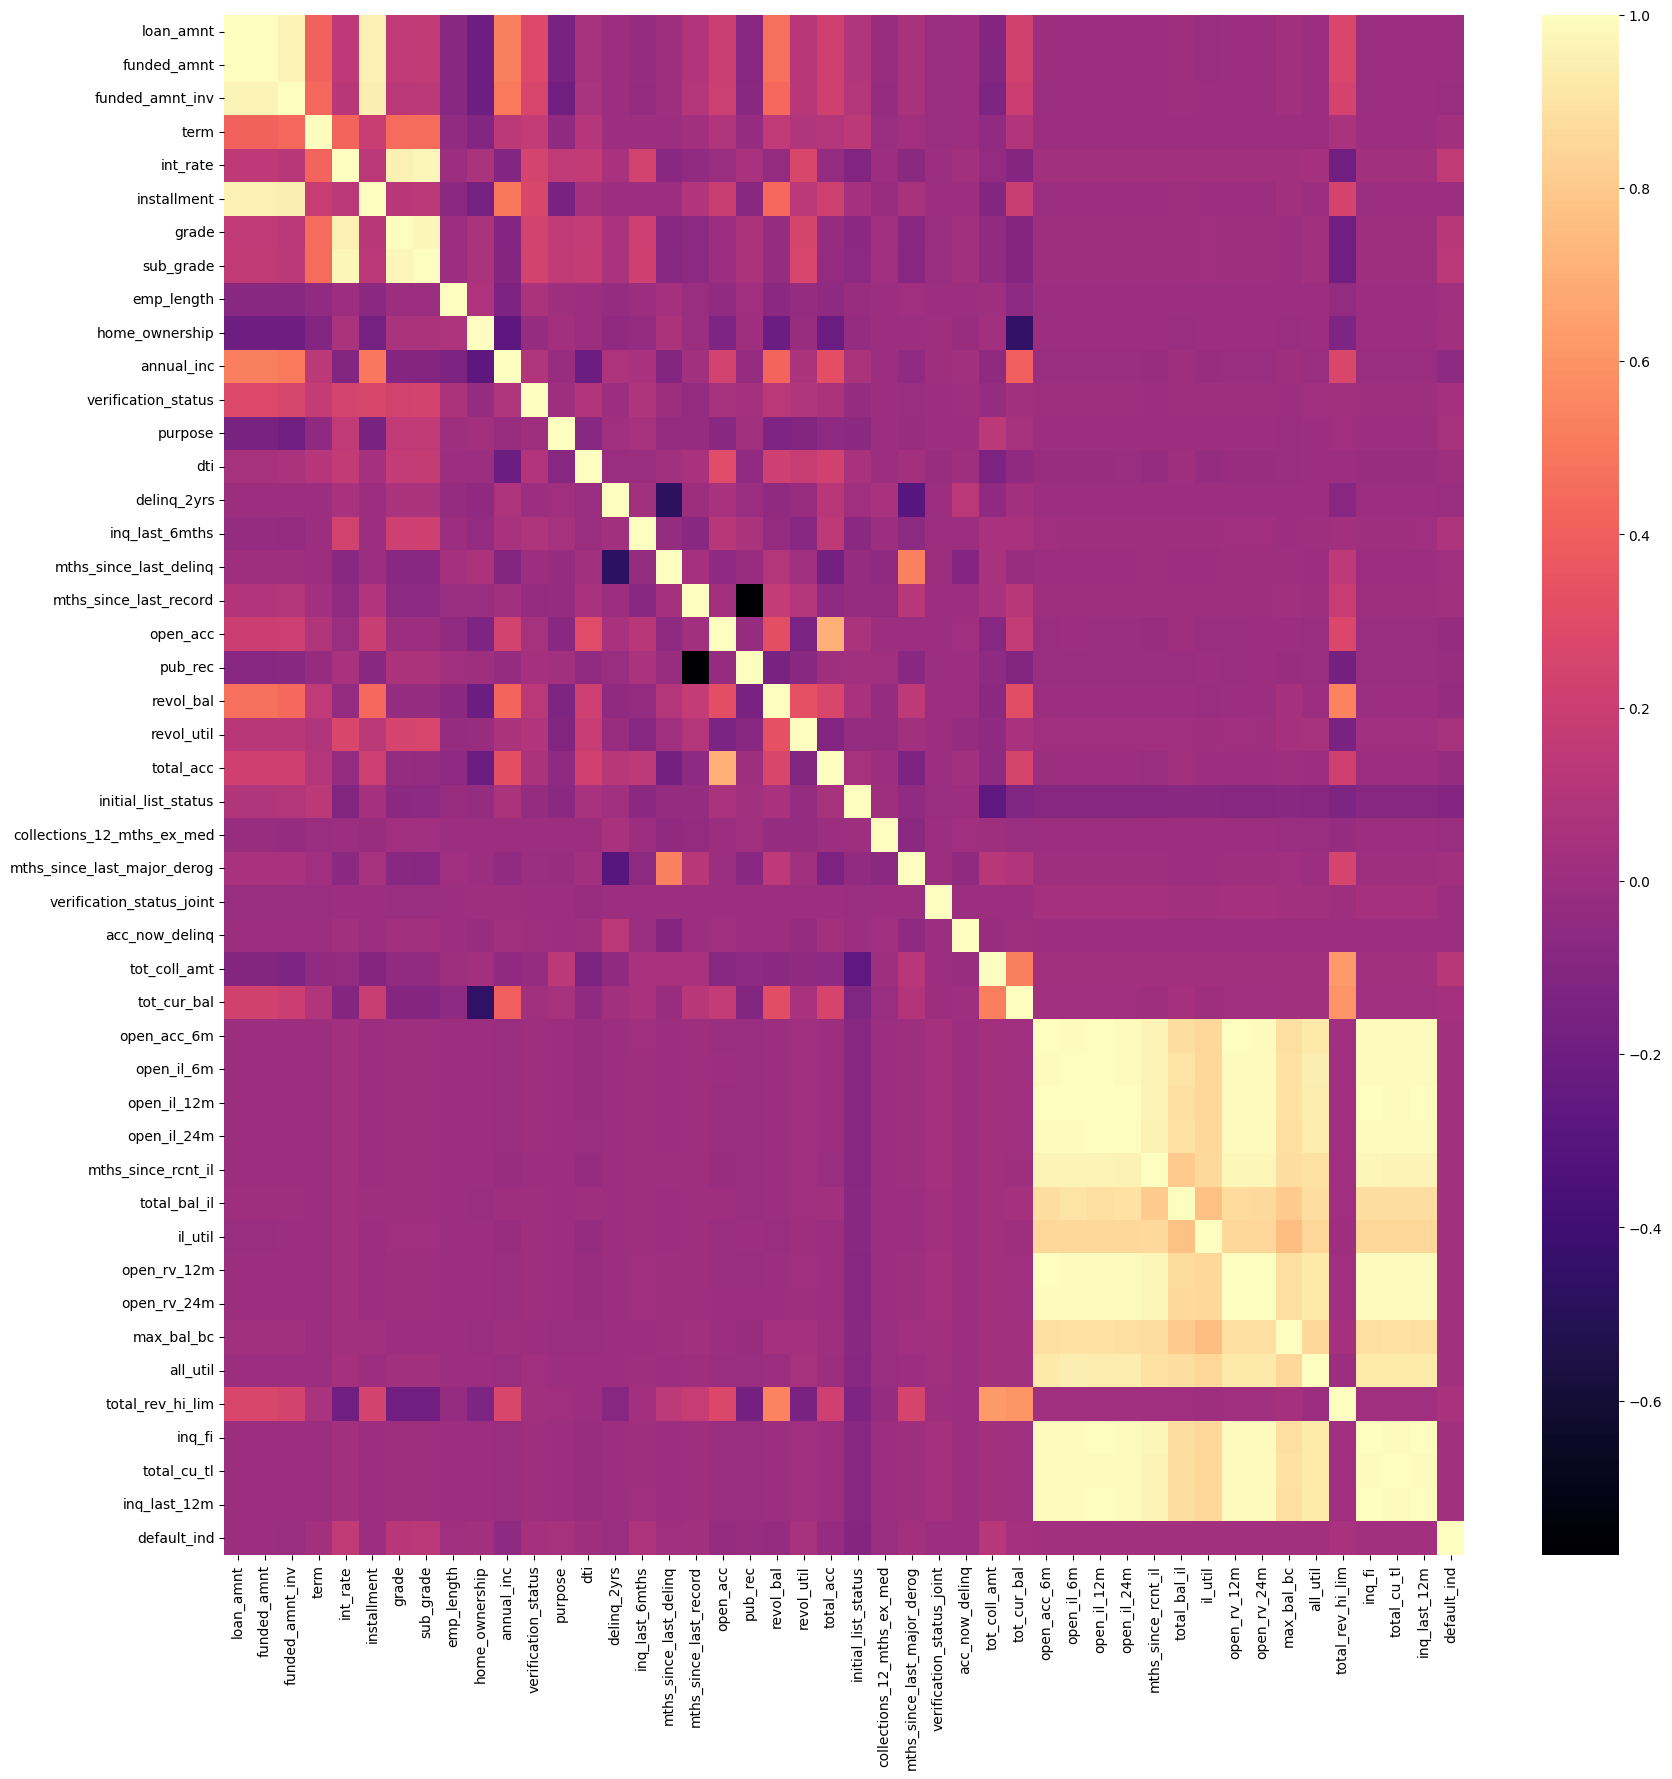

In [309]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(),annot=False,cmap='magma')

#Verificando as variáveis contínuas através da geração de gráficos de densidade (Density Plots), que são usados para observar a distribuição de uma variável em um conjunto de dados.

#Eles plotam o gráfico em um intervalo contínuo ou período de tempo. Uma vantagem dos Gráficos de Densidade sobre os Histogramas é que eles são melhores para determinar o formato da distribuição, pois não são afetados pelo número de intervalos (bins).

Text(0.5, 1.0, 'Total committed by Investors')

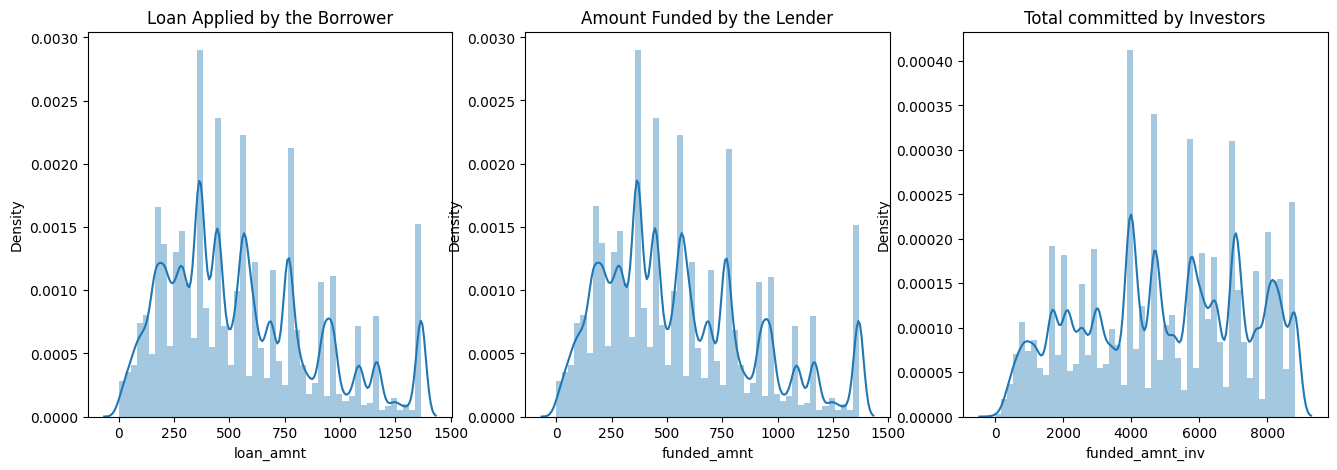

In [310]:
fig, ax = plt.subplots(1, 3, figsize=(16,5))
sns.distplot(data['loan_amnt'],ax=ax[0])
sns.distplot(data['funded_amnt'], ax=ax[1])
sns.distplot(data['funded_amnt_inv'], ax=ax[2])

ax[1].set_title("Amount Funded by the Lender")
ax[0].set_title("Loan Applied by the Borrower")
ax[2].set_title("Total committed by Investors")

###Após plotar o mapa de calor, encontramos variáveis com correlação muito baixa e algumas variáveis com a mesma distribuição.

###Trataremos o modelo como amostrado desnecessariamente (repetitivo), e também encontramos algumas variáveis altamente enviesadas (skewed).

In [311]:
data=data.drop(['funded_amnt_inv','funded_amnt','delinq_2yrs','collections_12_mths_ex_med','acc_now_delinq',
                        'tot_coll_amt'],axis=1)

### Dividindo os dados em Dataframes Independentes e Dependentes.

#### Dividindo o conjunto de dados em X e Y.

In [312]:
X = data.drop('default_ind', axis=1)
y = data['default_ind']

In [313]:
type(X)

pandas.DataFrame

In [314]:
print(X.shape)
print(y.shape)

(855969, 39)
(855969,)


#### Gerando o gráfico de contagem (count plot) para a variável dependente, identificando o desbalanceamento dos dados e aplicando a técnica de oversampling.

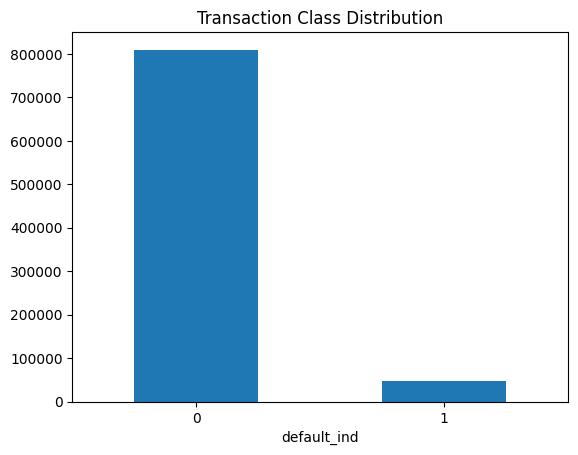

In [315]:
count_classes = data['default_ind'].value_counts(sort=True)

count_classes.plot(kind='bar', rot=0)

plt.title("Transaction Class Distribution")

plt.xticks(range(len(count_classes)))

plt.show()

### Reamostragem dos dados (Resampling).

#### Primeiro, vamos dividir os números binários classificados em duas variáveis separadas: 'aprovado' e 'rejeitado'.

In [316]:
approved = data[data['default_ind']==1]

reject = data[data['default_ind']==0]

#### Agora vamos verificar o formato (shape) dos 0s e 1s armazenados em diferentes variáveis.

In [317]:
print(approved.shape,reject.shape)

(46467, 40) (809502, 40)


#### Realizando a técnica SMOTE para lidar com dados desbalanceados. O pacote imblearn auxilia na identificação dos dados desbalanceados e na execução da técnica de sobreamostragem (oversampling) para o modelo.

In [318]:
#Estava usando o RandomOverSampler, mas decidi mudar para SMOTE, uma vez que o RandomOverSampler apenas duplica linhas existentes,
# evitando o Overfitting.

'''
from imblearn.over_sampling import RandomOverSampler
os = RandomOverSampler()
X_o_res, Y_o_res = os.fit_sample(X, Y)
'''

from imblearn.over_sampling import SMOTE

# Usando SMOTE puro em vez de SMOTETomek para otimizar o tempo de execução
smk = SMOTE(random_state=42)

X_o_res, Y_o_res = smk.fit_resample(X, y)

In [319]:
print(X_o_res.shape,Y_o_res.shape)

(1619004, 39) (1619004,)


#### Estamos imprimindo os valores do conjunto de dados original e os valores após a sobreamostragem (SMOTE).

In [320]:
from collections import Counter
print('Original dataset shape {}'.format(Counter(y)))
print('Resampled dataset shape {}'.format(Counter(Y_o_res)))

Original dataset shape Counter({0: 809502, 1: 46467})
Resampled dataset shape Counter({0: 809502, 1: 809502})


In [321]:
data

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,verification_status_joint,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1077501,167,0,101,8723,1,6,1,5,3120,2,1,2765,1,155,123,3,0,13648,923,7,0,167,3,322286,11,34,12,16,188,11099,1195,15,25,8114,1077,20793,16,27,27,0
1077430,67,1,273,1565,2,13,10,5,5579,1,0,100,5,155,123,3,0,1687,122,2,0,167,3,322286,11,34,12,16,188,11099,1195,15,25,8114,1077,20793,16,27,27,1
1077175,63,0,296,3098,2,14,1,5,410,0,11,872,2,155,123,2,0,2956,1073,8,0,167,3,322286,11,34,12,16,188,11099,1195,15,25,8114,1077,20793,16,27,27,0
1076863,367,0,197,23285,2,10,1,5,16788,1,9,2000,1,35,123,10,0,5598,250,35,0,167,3,322286,11,34,12,16,188,11099,1195,15,25,8114,1077,20793,16,27,27,0
1075358,87,1,166,2049,1,9,0,5,33015,1,9,1794,0,38,123,15,0,27783,613,36,0,167,3,322286,11,34,12,16,188,11099,1195,15,25,8114,1077,20793,16,27,27,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36371250,367,0,142,22657,1,9,8,5,6038,2,2,2869,0,155,77,9,1,14037,907,13,0,167,3,24632,11,34,12,16,188,11099,1195,15,25,8114,1077,3078,16,27,27,0
36441262,927,0,142,56733,1,9,1,1,32634,2,4,390,1,26,123,5,0,8621,931,21,0,29,3,125033,11,34,12,16,188,11099,1195,15,25,8114,1077,1235,16,27,27,0
36271333,487,1,297,21272,3,16,5,5,8091,2,2,3090,0,155,84,9,1,11031,693,20,1,167,3,33533,11,34,12,16,188,11099,1195,15,25,8114,1077,3333,16,27,27,0


In [322]:
colunas_originais = X.columns

In [323]:
colunas_originais

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'purpose', 'dti', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status',
       'mths_since_last_major_derog', 'verification_status_joint',
       'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m'],
      dtype='str')

In [324]:
scaler = StandardScaler()
scaler.fit(X_o_res)
X_o_res=scaler.transform(X_o_res)

X_o_res = pd.DataFrame(X_o_res, columns=colunas_originais)
print(X_o_res)

         loan_amnt      term  int_rate  installment     grade  sub_grade  \
0        -1.156351 -0.562222 -1.030775    -1.249911 -0.743746  -0.996701   
1        -1.455752  1.778658  0.293496    -1.669253  0.066937   0.117456   
2        -1.467728 -0.562222  0.470579    -1.579444  0.066937   0.276621   
3        -0.557548 -0.562222 -0.291647    -0.396816  0.066937  -0.360040   
4        -1.395872  1.778658 -0.530324    -1.640898 -0.743746  -0.519206   
...            ...       ...       ...          ...       ...        ...   
1618999   0.265807 -0.562222  0.578369     0.324232  0.066937   0.594951   
1619000   1.723892  1.778658  1.918039     1.656659  1.688304   1.868274   
1619001  -0.877907 -0.562222  0.239602    -0.819907  0.066937  -0.041710   
1619002   0.661017  1.778658  0.432083     0.339932  0.066937  -0.041710   
1619003  -0.318026 -0.562222  1.009527     0.086558  0.066937   0.435786   

         emp_length  home_ownership  annual_inc  verification_status  \
0         -0.91

In [325]:
# Cálculo do MI Score
mi_scores = mutual_info_classif(X_o_res, Y_o_res)

# Ranking crescente (menor MI = menos informativa)
mi_ranking = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

# Exibir top e bottom features
display(mi_ranking.head(10))   # 10 menos relevantes
display(mi_ranking.tail(10))   # 10 mais relevantes

revol_bal                    0.000831
verification_status_joint    0.002025
total_acc                    0.009059
dti                          0.010997
open_acc                     0.014813
tot_cur_bal                  0.020534
il_util                      0.020545
open_il_24m                  0.021196
mths_since_rcnt_il           0.021206
total_bal_il                 0.021262
dtype: float64

term                           0.103786
mths_since_last_major_derog    0.137260
mths_since_last_delinq         0.137691
home_ownership                 0.154116
loan_amnt                      0.208876
installment                    0.242311
initial_list_status            0.258065
annual_inc                     0.314890
int_rate                       0.338380
total_rev_hi_lim               0.420784
dtype: float64

In [326]:
percentuais = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
resultados = []

In [327]:
def run_experimento(modelo_nome, model, X_train, X_val, y_train, y_val, return_preds=False):
    print(f"\nTreinando modelo: {modelo_nome}...")

    tracker = EmissionsTracker()
    tracker.start()
    start_time = time.time()

    try:
        if modelo_nome == 'RNA':
            model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)
            y_pred_proba = model.predict(X_val).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_val)[:, 1]
            elif hasattr(model, "decision_function"):
                y_pred_proba = 1 / (1 + np.exp(-model.decision_function(X_val)))
            else:
                y_pred_proba = np.clip(y_pred.astype(float), 0, 1)

    finally:
        emissions_kg = tracker.stop()
        emissions_g = emissions_kg * 1000
        energia = tracker._total_energy.kWh
        tempo = time.time() - start_time

    # Métricas clássicas
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    brier = brier_score_loss(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba) if len(np.unique(y_val)) == 2 else np.nan

    # Métrica ambiental
    rga = emissions_g / acc if acc > 0 else float('inf')

    print(f"{modelo_nome} concluído.")
    print(f"Acurácia: {acc:.4f} | Precisão: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"AUC: {auc:.4f} | Brier: {brier:.6f}")
    print(f"Energia: {energia:.6f} kWh | Emissões: {emissions_g:.6f} gCO₂eq")
    print(f"RGA: {rga:.6f} | Tempo: {tempo:.2f}s\n")

    if return_preds:
        return (
            acc, prec, rec, f1, brier, auc,
            tempo, emissions_g, energia, rga,
            y_pred, y_pred_proba
        )
    else:
        return acc, prec, rec, f1, brier, auc, tempo, emissions_g, energia, rga


In [328]:
for p in percentuais:
    print(f"Redução de {int(p*100)}%:")

    n_remove = int(len(mi_ranking) * p)
    cols_reduzido = mi_ranking.index[n_remove:]  # Mantém as mais relevantes
    X_reduz = X_o_res[cols_reduzido]

    print(f"Antes: {X_o_res.shape[1]} features")
    print(f"Removidas: {n_remove}")
    print(f"Depois: {X_reduz.shape[1]} features")

    X_train, X_val, y_train, y_val = train_test_split(
        X_reduz, Y_o_res, test_size=0.3, random_state=10
    )

    modelos = {
        "RandomForest": RandomForestClassifier(n_estimators=30, random_state=10),
        "LightGBM": LGBMClassifier(n_estimators=30, random_state=10),
        "RNA": Sequential([
            Dense(64, input_dim=X_train.shape[1], activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    }

    for nome, modelo in modelos.items():
        if nome == "RNA":
            modelo.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

        acc, prec, rec, f1, brier, auc, tempo, em, energia, rga, y_pred, y_prob = run_experimento(
            nome, modelo, X_train, X_val, y_train, y_val, return_preds=True
        )

        # Métricas calculadas após cada modelo
        f1 = f1_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        brier = brier_score_loss(y_val, y_prob)
        auc = roc_auc_score(y_val, y_prob)
        rga = em / acc if acc > 0 else float('inf')

        resultados.append([
            nome,
            f"-{int(p*100)}%",
            X_reduz.shape[1],
            acc,
            prec,
            rec,
            f1,
            brier,
            auc,
            tempo,
            energia,
            em,
            rga
        ])

print("Todos os experimentos finalizados!\n")


Redução de 0%:
Antes: 39 features
Removidas: 0
Depois: 39 features


E0000 00:00:1772650694.140452   23004 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772650694.146166   23004 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
[codecarbon WARNING @ 15:58:15] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:58:15] [setup] RAM Tracking...
[codecarbon INFO @ 15:58:15] [setup] CPU Tracking...
[codecarbon WARNING @ 15:58:15] 	RAPL - Permission denied reading RAPL file /sys/class/powercap/intel-rapl/subsystem/intel-rapl/intel-rapl:0/energy_uj. You can grant read permission with: sud


Treinando modelo: RandomForest...


[codecarbon WARNING @ 15:58:17] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 15:58:17] CPU Model on constant consumption mode: Intel(R) Xeon(R) W-1350 @ 3.30GHz
[codecarbon WARNING @ 15:58:17] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 15:58:17] [setup] GPU Tracking...
[codecarbon INFO @ 15:58:17] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 15:58:17] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 15:58:17] >>> Tracker's metadata:
[codecarbon INFO @ 15:58:17]   Platform system: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
[codecarbon INFO @ 15:58:17]   Python version: 3.12.3
[codecarbon

RandomForest concluído.
Acurácia: 0.9544 | Precisão: 0.9700 | Recall: 0.9379 | F1: 0.9537
AUC: 0.9881 | Brier: 0.041677
Energia: 0.000797 kWh | Emissões: 0.078355 gCO₂eq
RGA: 0.082097 | Tempo: 75.68s


Treinando modelo: LightGBM...


...

LightGBM concluído.
Acurácia: 0.9024 | Precisão: 0.9257 | Recall: 0.8752 | F1: 0.8998
AUC: 0.9653 | Brier: 0.077667
Energia: 0.000022 kWh | Emissões: 0.002129 gCO₂eq
RGA: 0.002359 | Tempo: 1.97s


Treinando modelo: RNA...


[codecarbon INFO @ 16:59:10] Emissions data (if any) will be saved to file /home/enginelab/Everton /XYZ_CorpLending/Codecarbon/emissions.csv
[codecarbon INFO @ 16:59:26] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:59:26] Delta energy consumed for CPU with cpu_load : 0.000038 kWh, power : 8.441976065600002 W
[codecarbon INFO @ 16:59:26] Energy consumed for All CPU : 0.000038 kWh
[codecarbon INFO @ 16:59:27] Energy consumed for all GPUs : 0.000070 kWh. Total GPU Power : 15.333829479896584 W
[codecarbon INFO @ 16:59:27] 0.000152 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 16:59:41] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:59:41] Delta energy consumed for CPU with cpu_load : 0.000034 kWh, power : 8.38531232 W
[codecarbon INFO @ 16:59:41] Energy consumed for All CPU : 0.000071 kWh
[codecarbon INFO @ 16:59:42] Energy consumed for all GPUs : 0.000150 kWh. Total GPU Pow

15179/15179 ━━━━━━━━━━━━━━━━━━━━ 5s 341us/step


[codecarbon INFO @ 17:10:07] Energy consumed for RAM : 0.001765 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:10:08] Delta energy consumed for CPU with cpu_load : 0.000025 kWh, power : 8.232703900307692 W
[codecarbon INFO @ 17:10:08] Energy consumed for All CPU : 0.001458 kWh
[codecarbon INFO @ 17:10:08] Energy consumed for all GPUs : 0.003392 kWh. Total GPU Power : 18.67217146844607 W
[codecarbon INFO @ 17:10:08] 0.006616 kWh of electricity and 0.000000 L of water were used since the beginning.


RNA concluído.
Acurácia: 0.9245 | Precisão: 0.9566 | Recall: 0.8895 | F1: 0.9218
AUC: 0.9769 | Brier: 0.054829
Energia: 0.006616 kWh | Emissões: 0.650652 gCO₂eq
RGA: 0.703811 | Tempo: 656.99s

Todos os experimentos finalizados!



In [ ]:
df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Redução",
        "N_Features",
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Brier",
        "AUC",
        "Tempo (s)",
        "Energia (kWh)",
        "Emissoes (g)",
        "RGA"
    ]
)

df_resultados.to_csv(
    "/home/enginelab/Everton /XYZ_CorpLending/Codecarbon/[REDUCAO - CODECARBON]resultados_experimentos[XYZ_Corp].csv",
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print("\n✅ Prévia dos resultados:")
display(df_resultados.head())



✅ Prévia dos resultados:


,Modelo,Redução,N_Features,Acurácia,Precisão,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA
0,RandomForest,-0%,39,0.954421,0.970027,0.937924,0.953705,0.041677,0.988147,75.683093,0.000797,0.078355,0.082097
1,LightGBM,-0%,39,0.902605,0.925950,0.875437,0.899985,0.077562,0.965476,3.143296,0.000047,0.004648,0.005150
2,RNA,-0%,39,0.924246,0.966034,0.879587,0.920786,0.054998,0.977084,637.474713,0.006386,0.628096,0.679576
3,RandomForest,-10%,36,0.953352,0.969692,0.936065,0.952582,0.041726,0.987625,63.426396,0.000534,0.052515,0.055085
4,LightGBM,-10%,36,0.902640,0.925989,0.875470,0.900021,0.077551,0.965481,2.477443,0.000028,0.002742,0.003038


### AUMENTO DAS FEATURES

In [330]:
def signed_log(series):
    arr = series.to_numpy(dtype=float)
    return np.sign(arr) * np.log1p(np.abs(arr))

def safe_log1p_nonneg(series):
    arr = series.to_numpy(dtype=float)
    arr = np.where(arr > 0, arr, 0.0)
    return np.log1p(arr)

In [331]:
def aumentar_features(df, percent_increase):

    df_new = df.copy()
    epsilon = 1e-6

    print(f"\n--- Aumento de {percent_increase}% ---")

    # =========================
    # 🔹 NÍVEL 10% (Razões básicas de risco)
    # =========================
    if percent_increase >= 10:

        df_new['feat_loan_vs_income'] = df_new['loan_amnt'] / (df_new['annual_inc'] + epsilon)
        df_new['feat_installment_vs_income'] = df_new['installment'] / (df_new['annual_inc'] + epsilon)
        df_new['feat_revol_bal_vs_income'] = df_new['revol_bal'] / (df_new['annual_inc'] + epsilon)
        df_new['feat_totalacc_ratio'] = df_new['open_acc'] / (df_new['total_acc'] + epsilon)


    # =========================
    # 🔹 NÍVEL 20% (Endividamento + crédito)
    # =========================
    if percent_increase >= 20:

        df_new['feat_credit_pressure'] = df_new['dti'] * df_new['revol_util']
        df_new['feat_inq_intensity'] = df_new['inq_last_6mths'] + df_new['inq_last_12m']
        df_new['feat_delinq_risk'] = df_new['mths_since_last_delinq'] / (df_new['total_acc'] + epsilon)
        df_new['feat_pubrec_ratio'] = df_new['pub_rec'] / (df_new['total_acc'] + epsilon)


    # =========================
    # 🔹 NÍVEL 30% (Logs financeiros)
    # =========================
    if percent_increase >= 30:

        df_new['feat_log_loan'] = safe_log1p_nonneg(df_new['loan_amnt'])
        df_new['feat_log_income'] = safe_log1p_nonneg(df_new['annual_inc'])
        df_new['feat_log_revol_bal'] = safe_log1p_nonneg(df_new['revol_bal'])
        df_new['feat_log_tot_cur_bal'] = safe_log1p_nonneg(df_new['tot_cur_bal'])


    # =========================
    # 🔹 NÍVEL 40% (Interações fortes de risco)
    # =========================
    if percent_increase >= 40:

        df_new['feat_dti_x_loan'] = df_new['dti'] * df_new['loan_amnt']
        df_new['feat_int_x_term'] = df_new['int_rate'] * df_new['term']
        df_new['feat_income_x_grade'] = df_new['annual_inc'] * df_new['grade']
        df_new['feat_revol_x_util'] = df_new['revol_bal'] * df_new['revol_util']


    # =========================
    # 🔹 NÍVEL 50% (Polinômios e pressão sistêmica)
    # =========================
    if percent_increase >= 50:

        df_new['feat_dti_sq'] = df_new['dti'] ** 2
        df_new['feat_int_sq'] = df_new['int_rate'] ** 2
        df_new['feat_loan_sq'] = df_new['loan_amnt'] ** 2
        df_new['feat_income_minus_debtproxy'] = df_new['annual_inc'] - df_new['loan_amnt']


    # =========================
    # 🔹 Limpeza final
    # =========================
    df_new = df_new.replace([np.inf, -np.inf], np.nan)
    df_new = df_new.fillna(0)

    print("Total de features:", df_new.shape[1])

    return df_new

In [ ]:
percentuais_aumento = [0.1, 0.2, 0.3, 0.4, 0.5]
resultados_aumento = []

X_original = X_o_res.copy()
y_original = Y_o_res.copy()

for p in percentuais_aumento:
    nivel_percentual = int(p * 100)
    print(f"\n--- Iniciando experimento para AUMENTO de {nivel_percentual}% ---")

    X_aumentado = aumentar_features(X_original, nivel_percentual)

    print(f"Features Originais: {X_original.shape[1]}")
    n_adicionadas = X_aumentado.shape[1] - X_original.shape[1]
    print(f"Features Adicionadas: {n_adicionadas}")
    print(f"Features Totais: {X_aumentado.shape[1]}\n")

    X_train, X_val, y_train, y_val = train_test_split(
        X_aumentado, y_original, test_size=0.3, random_state=10 + nivel_percentual
    )

    print(f"Tamanho de entrada para RNA: {X_train.shape[1]} features")

    modelos = {
        "RandomForest": RandomForestClassifier(n_estimators=30, random_state=10),
        "LightGBM": LGBMClassifier(n_estimators=30, random_state=10),
        "RNA": Sequential([
            Dense(64, input_dim=X_train.shape[1], activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    }

    for nome, modelo in modelos.items():
        if nome == "RNA":
            modelo.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

        acc, prec, rec, f1, brier, auc, tempo, em, energia, rga, y_pred, y_prob = run_experimento(
            nome, modelo, X_train, X_val, y_train, y_val, return_preds=True
        )

        resultados_aumento.append([
            nome,
            f"+{nivel_percentual}%",
            X_aumentado.shape[1],
            acc, prec, rec, f1, brier, auc, tempo, energia, em, rga
        ])

print("\n--- Todos os experimentos de AUMENTO finalizados! ---")

colunas = ["Modelo", "Alteração", "N_Features", "Accuracy", "Precision", "Recall",
            "F1", "Brier", "AUC", "Tempo", "Energia", "EM", "RGA"]

resultados_aumento_df = pd.DataFrame(resultados_aumento, columns=colunas)



--- Iniciando experimento para AUMENTO de 10% ---

--- Aumento de 10% ---
Total de features: 43
Features Originais: 39
Features Adicionadas: 4
Features Totais: 43

Tamanho de entrada para RNA: 43 features


[codecarbon WARNING @ 17:10:15] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:10:15] [setup] RAM Tracking...
[codecarbon INFO @ 17:10:15] [setup] CPU Tracking...
[codecarbon WARNING @ 17:10:15] 	RAPL - Permission denied reading RAPL file /sys/class/powercap/intel-rapl/subsystem/intel-rapl/intel-rapl:0/energy_uj. You can grant read permission with: sudo chmod -R a+r /sys/class/powercap/*
[codecarbon WARNING @ 17:10:15] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 17:10:15] CPU Model on constant consumption mode: Intel(R) Xeon(R) W-1350 @ 3.30GHz
[codecarbon WARNING @ 17:10:15] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 17:10:15] [setup] GPU Tracking...
[codecarbon INFO @ 17:10:15] Tracking Nvidia GPU via pynvml
[codecarbon INFO 


Treinando modelo: RandomForest...


[codecarbon INFO @ 17:10:18] Emissions data (if any) will be saved to file /home/enginelab/Everton /XYZ_CorpLending/Codecarbon/emissions.csv
[codecarbon INFO @ 17:10:34] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:10:35] Delta energy consumed for CPU with cpu_load : 0.000036 kWh, power : 8.154113734400003 W
[codecarbon INFO @ 17:10:35] Energy consumed for All CPU : 0.000036 kWh
[codecarbon INFO @ 17:10:35] Energy consumed for all GPUs : 0.000074 kWh. Total GPU Power : 16.1059862783578 W
[codecarbon INFO @ 17:10:35] 0.000155 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 17:10:49] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:10:50] Delta energy consumed for CPU with cpu_load : 0.000033 kWh, power : 8.176819742000001 W
[codecarbon INFO @ 17:10:50] Energy consumed for All CPU : 0.000069 kWh
[codecarbon INFO @ 17:10:50] Energy consumed for all GPUs : 0.000141 kWh. Total GP

RandomForest concluído.
Acurácia: 0.9553 | Precisão: 0.9694 | Recall: 0.9404 | F1: 0.9547
AUC: 0.9887 | Brier: 0.041818
Energia: 0.000855 kWh | Emissões: 0.084039 gCO₂eq
RGA: 0.087969 | Tempo: 90.29s


Treinando modelo: LightGBM...


...

LightGBM concluído.
Acurácia: 0.8980 | Precisão: 0.9220 | Recall: 0.8695 | F1: 0.8950
AUC: 0.9637 | Brier: 0.079296
Energia: 0.000044 kWh | Emissões: 0.004324 gCO₂eq
RGA: 0.004815 | Tempo: 3.51s


Treinando modelo: RNA...


[codecarbon INFO @ 18:04:20] Emissions data (if any) will be saved to file /home/enginelab/Everton /XYZ_CorpLending/Codecarbon/emissions.csv
[codecarbon INFO @ 18:04:36] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:04:37] Delta energy consumed for CPU with cpu_load : 0.000036 kWh, power : 8.1396534608 W
[codecarbon INFO @ 18:04:37] Energy consumed for All CPU : 0.000036 kWh
[codecarbon INFO @ 18:04:37] Energy consumed for all GPUs : 0.000053 kWh. Total GPU Power : 11.519076178502536 W
[codecarbon INFO @ 18:04:37] 0.000134 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:04:51] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:04:52] Delta energy consumed for CPU with cpu_load : 0.000033 kWh, power : 8.143484192 W
[codecarbon INFO @ 18:04:52] Energy consumed for All CPU : 0.000069 kWh
[codecarbon INFO @ 18:04:52] Energy consumed for all GPUs : 0.000104 kWh. Total GPU Power :

15179/15179 ━━━━━━━━━━━━━━━━━━━━ 5s 328us/step


[codecarbon INFO @ 18:15:05] Energy consumed for RAM : 0.001731 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:15:05] Delta energy consumed for CPU with cpu_load : 0.000030 kWh, power : 8.172210406400001 W
[codecarbon INFO @ 18:15:05] Energy consumed for All CPU : 0.001410 kWh
[codecarbon INFO @ 18:15:05] Energy consumed for all GPUs : 0.002145 kWh. Total GPU Power : 12.303458761277984 W
[codecarbon INFO @ 18:15:05] 0.005286 kWh of electricity and 0.000000 L of water were used since the beginning.


RNA concluído.
Acurácia: 0.9173 | Precisão: 0.9570 | Recall: 0.8738 | F1: 0.9135
AUC: 0.9745 | Brier: 0.059272
Energia: 0.005286 kWh | Emissões: 0.519882 gCO₂eq
RGA: 0.566745 | Tempo: 644.14s


--- Todos os experimentos de AUMENTO finalizados! ---


In [333]:
df_resultados = pd.DataFrame(
    resultados_aumento,
    columns=[
        "Modelo",
        "Redução",
        "N_Features",
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Brier",
        "AUC",
        "Tempo (s)",
        "Energia (kWh)",
        "Emissoes (g)",
        "RGA"
    ]
)


caminho_saida = "/home/enginelab/Everton /XYZ_CorpLending/Codecarbon/[AUMENTO - CODECARBON]resultados_experimentos[XYZ_Corp].csv"
df_resultados.to_csv(
    caminho_saida,
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print(f"Resultados salvos em: {caminho_saida}")
print("\n✅ Prévia dos resultados:")
display(df_resultados.head())

Resultados salvos em: /home/enginelab/Everton /XYZ_CorpLending/Codecarbon/[AUMENTO - CODECARBON]resultados_experimentos[XYZ_Corp].csv

✅ Prévia dos resultados:


,Modelo,Redução,N_Features,Acurácia,Precisão,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA
0,RandomForest,+10%,43,0.955322,0.969429,0.940412,0.954700,0.041818,0.988709,90.288252,0.000855,0.084039,0.087969
1,LightGBM,+10%,43,0.898228,0.923766,0.868372,0.895213,0.080126,0.963140,3.090810,0.000042,0.004124,0.004591
2,RNA,+10%,43,0.918954,0.950739,0.883909,0.916107,0.058120,0.975357,666.510918,0.006306,0.620231,0.674931
3,RandomForest,+20%,47,0.954447,0.966335,0.941452,0.953731,0.043459,0.988651,100.105633,0.000997,0.098045,0.102724
4,LightGBM,+20%,47,0.899197,0.922216,0.871355,0.896065,0.079337,0.963861,3.842692,0.000052,0.005103,0.005675
